#INFORMACIÓN GENERAL

UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO

ESCUELA PROFESIONAL DE INGENIERÍA INFORMÁTICA Y DE SISTEMAS

INTELIGENCIA ARTIFICIAL

REGRESIÓN LINEAL MÚLTIPLE


#REGRESIÓN LINEAL MÚLTIPLE

Este material utiliza el problema planteado en: http://eio.usc.es/eipc1/BASE/BASEMASTER/FORMULARIOS-PHP-DPTO/MATERIALES/Mat_50140128_RegresionMultiple.pdf

##Introducción



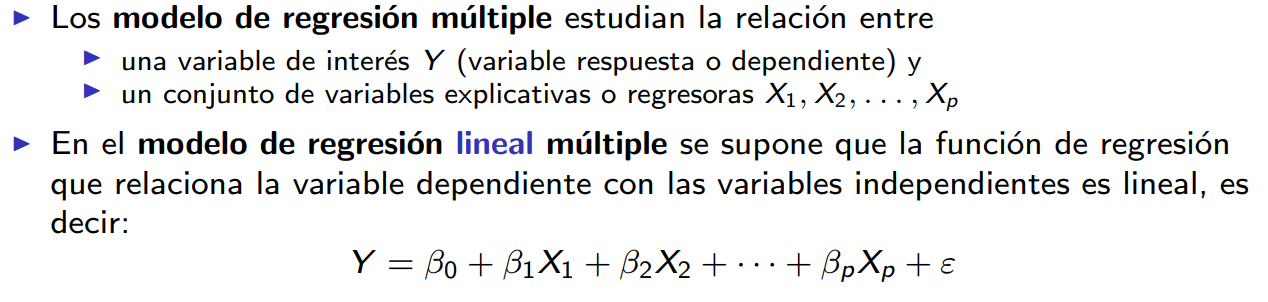

Supongamos que estamos interesados en encontrar un hábitat adecuado para la familia de los escarabajos tigre (Cicindela dorsalis dorsalis), que viven en playas arenosas de la costa atlántica de Norteamérica.
Un posible procedimiento a seguir sería acudir a diferentes playas en las que habitase la especie y medir en ellas la densidad del escarabajo ($Y$) junto con distintos factores bióticos y abióticos (exposición al oleaje, tamaño del grano de arena, densidad de otros organismos,...)
Un modelo de regresión múltiple nos daría una ecuación para relacionar la densidad del escarabajo con el resto de variables, de modo que si acudimos a una nueva playa en la que no hay escarabajos y medimos el resto de factores podríamos predecir la densidad esperada de escarabajos al introducir la especie.

##Enunciado del problema

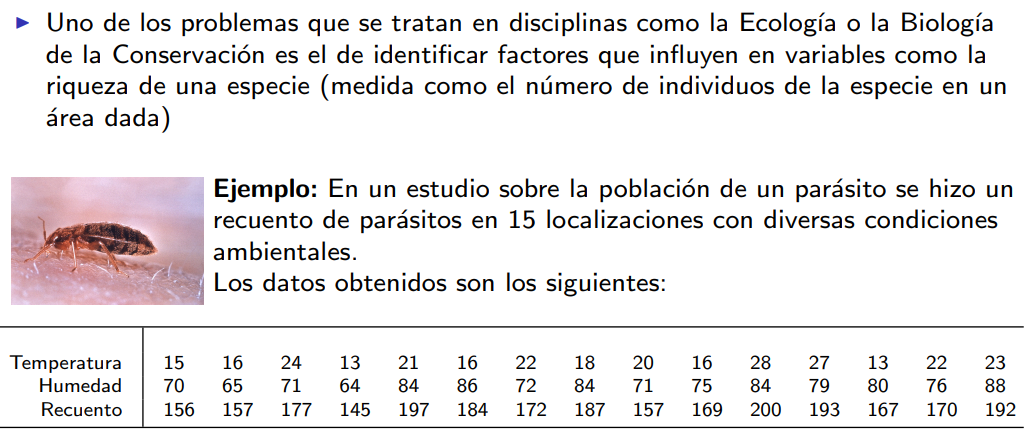

##Aplicación de Machine Learning

Librerías básicas

In [ ]:
import numpy as np
import pandas as pd

###$Fase 1$: Recolección de datos

En el caso de este ejercicio, ya contamos con los datos; por tanto, no se requerirá recolectar datos; éstos ya están el archivo: $Población parasitos.csv$.

In [ ]:
# -- Recuperar datos. Leer el dataset mediante el método "read_csv"
NombreArchivo = 'PoblacionParasito.csv'
ds = pd.read_csv(NombreArchivo)

###$Fase 2$: Pre procesamiento de los datos

En el caso de este ejercicio, los datos no presentan ningún tipo de anomalías o inconsistencias; por lo tanto, no se requiere ningún tipo de pre procesamiento.

###$Fase 3$: Elegir el modelo

De acuerdo al enunciado y la naturaleza del problema, se utilizará el modelo de "Regresión lineal múltiple". En función al modelo, se elige las librerías requeridas.

Librerías requeridas para el modelo

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

El modelo elegido para este problema es $LinearRegression$, el cuál se encuentra en la librería $sklear.linear\_model$.

Tener en cuenta que la librería estándar de aprendizaje automático es $sklearn$; la cual, contine muchos modelos de aprendizaje automático.

Así mismo, se utiliza la librería $sklearn.metrics$ que permitirá medir la bondad del modelo.

También se está utilizando una librería genérica $train\_test\_split$, que permitirá dividir el $dataset$ en dos partes, para entrenamiento y testeo.

###$Fase 4: $ Entrenar el modelo

In [ ]:
# -- Determinar las Variables independiente y dependiente
X = ds[['Temperatura','Humedad']]
y = ds.Recuento

# -- Separar los datos para el entrenamiento (train) y la validación (test),
#    considerando 80% para el entrenamiento y 20% para el testeo. Ver último parámetro
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# -- Utilizar el modelo elegido en la fase previa
rlm = LinearRegression()

# -- Entrenar el modelo invocando al método "fit" con los datos de entyrenamiento
rlm.fit(X_train, y_train)


LinearRegression()

###$Fase 5:$ Evaluar el modelo

In [ ]:
# -- Determinar la precisión de la fase de entrenamiento
score = rlm.score(X_train, y_train)
print('Fase de entrenamiento: ',score)
# -- Validar el modelo con los datos de testeo, efectuando una predicción
Y_pred = rlm.predict(X_test)
# -- Determinar la bondad del modelo en la fase de evaluación
error_cuadratico_medio = mean_squared_error(y_test, Y_pred)
coeficiente_de_determinacion = r2_score(y_test, Y_pred)

print("Error Cuadrático Medio:", error_cuadratico_medio)
print("Coeficiente de Determinación (R2):", coeficiente_de_determinacion)

Fase de entrenamiento:  0.9100636260751592
Error Cuadrático Medio: 19.367729044512572
Coeficiente de Determinación (R2): 0.7929815185265877


###$Fase 6:$ Configurar (Ajustar) hiperparámetros

No es necesario efectuar ajuste en los hiperparámetros, dado que el coeficiente de determinación es alto.

###$Fase 7:$ Predecir o inferir

En esta fase, se utiliza el modelo para predecir con datos correspondientes a nuevos escenarios.

En este caso, se debe determinar el recuento de parásitos para las temperaturas y humedades dadas en la siguiente tabla.

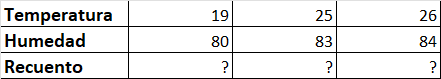

In [ ]:
# Los nuevos datos se pueden leer de un archivo csv, o con ellos se puede generar
# un dataframe en memoria.
# Se optará por el segundo caso

# Crear un diccionario con los datos de los nuevos escenarios
datos = {
    "ID": [1, 2, 3],
    "Temperatura": [15, 16, 24],
    "Humedad": [70, 65, 71],
    "Recuento": [0, 0, 0]
}

# Crear un DataFrame a partir del diccionario
ds = pd.DataFrame(datos)

# Datos de temperaturas y humedades correspondientes a nuevos escenarios
# x_datos = np.array([[19, 80], [25, 83], [26, 84]])
# Obtener las características (X) y etiquetas (y)
x_datos = ds[["Temperatura", "Humedad"]]

# Realizar las predicciones
y_predicciones = rlm.predict(x_datos)

# Mostrar resultados
for (temperatura, humedad), recuento in zip(x_datos.values, y_predicciones):
    print(f"Temperatura: {temperatura}°C",\
          f"Humedad: {humedad}%",\
          f"Predicción: {recuento:.2f}")


Temperatura: 15°C Humedad: 70% Predicción: 157.19
Temperatura: 16°C Humedad: 65% Predicción: 150.47
Temperatura: 24°C Humedad: 71% Predicción: 172.61


#EJERCICIO

Investigar un problema que requiera de Regresión lineal múltiple e implementar su respectiva solución